# Basal Sliding: Lecture Figures

**Ge 193 — Glacier Dynamics, Spring 2026**

This notebook generates figures for the *Basal Sliding* lecture, covering Weertman sliding theory, cavity formation, effective pressure effects, Mohr–Coulomb till behavior, and phenomenological sliding laws.

In [1]:
# ---- Setup: imports and physical constants ----
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# Physical constants
rho_i = 917.0       # kg m^{-3}, ice density
g = 9.8             # m s^{-2}
k_r = 2.5           # W m^{-1} K^{-1}, thermal conductivity of bedrock
B_cc = 7.4e-8       # K Pa^{-1}, Clausius-Clapeyron constant
L = 3.34e5          # J kg^{-1}, specific latent heat of fusion
rho_w = 1000.0      # kg m^{-3}, water density
sec_per_yr = 3.154e7  # s yr^{-1}

# Glen's flow law parameters
n_glen = 3
A_glen = 2.4e-24     # Pa^{-3} s^{-1} (at T ~ 263 K)

print('Setup complete.')

Setup complete.


---
## Figure 1: Regelation and Creep Velocities vs Bump Size

Show how the regelation velocity $u_1 \propto 1/a$ and the enhanced creep velocity $u_2 \propto a$ depend on bump size, and identify the controlling obstacle size $a_c$ where the total velocity is minimized.

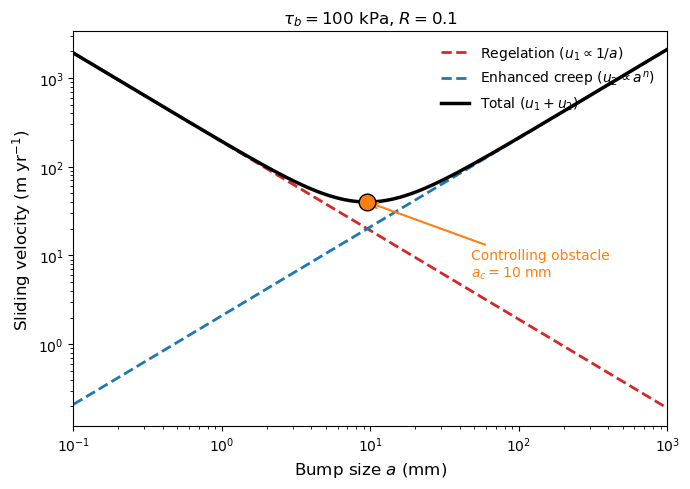

Controlling obstacle size: a_c = 9.5 mm
Figure 1 saved.


In [2]:
# ---- Fig 1: regelation and creep velocity vs bump size ----

def u_regelation(a, tau_b, R):
    """Regelation velocity (m/s). a in m, tau_b in Pa, R = a/lambda."""
    return k_r * B_cc / (rho_i * L * a) * tau_b / R**2


def u_creep(a, tau_b, R, A=A_glen, n=n_glen):
    """Enhanced creep velocity (m/s). a in m, tau_b in Pa."""
    return 2 * 3**(-(n+1)/2) * a * A * (tau_b / (2 * R**2))**n


tau_b_val = 100e3   # Pa (100 kPa)
R_val = 0.1         # roughness a/lambda

a_arr = np.logspace(-4, 0, 500)  # bump size in m (0.1 mm to 1 m)

u1 = u_regelation(a_arr, tau_b_val, R_val)
u2 = u_creep(a_arr, tau_b_val, R_val)
u_total = u1 + u2

# Controlling obstacle size: where u1 = u2
idx_cross = np.argmin(np.abs(np.log10(u1) - np.log10(u2)))
a_c = a_arr[idx_cross]
u_c = u_total[idx_cross]

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(a_arr * 1e3, u1 * sec_per_yr, '--', color='#d62728', lw=2,
          label='Regelation ($u_1 \\propto 1/a$)')
ax.loglog(a_arr * 1e3, u2 * sec_per_yr, '--', color='#1f77b4', lw=2,
          label='Enhanced creep ($u_2 \\propto a^n$)')
ax.loglog(a_arr * 1e3, u_total * sec_per_yr, 'k-', lw=2.5,
          label='Total ($u_1 + u_2$)')

# Mark controlling obstacle size
ax.plot(a_c * 1e3, u_c * sec_per_yr, 'o', color='#ff7f0e', ms=12, zorder=5,
        markeredgecolor='k', markeredgewidth=1)
ax.annotate(f'Controlling obstacle\n$a_c = {a_c*1e3:.0f}$ mm',
            xy=(a_c * 1e3, u_c * sec_per_yr),
            xytext=(a_c * 1e3 * 5, u_c * sec_per_yr * 0.3),
            fontsize=10, ha='left', va='top', color='#ff7f0e',
            arrowprops=dict(arrowstyle='->', color='#ff7f0e', lw=1.5))

ax.set_xlabel('Bump size $a$ (mm)', fontsize=12)
ax.set_ylabel('Sliding velocity (m yr$^{-1}$)', fontsize=12)
ax.set_title(f'$\\tau_b = {tau_b_val/1e3:.0f}$ kPa, $R = {R_val}$', fontsize=12)
ax.set_xlim(0.1, 1000)
ax.legend(loc='upper right', fontsize=10, frameon=False)

fig.tight_layout()
fig.savefig('figures/fig01_regelation_creep_vs_bump_size.pdf', bbox_inches='tight')
plt.show()
print(f'Controlling obstacle size: a_c = {a_c*1e3:.1f} mm')
print('Figure 1 saved.')

---
## Figure 2: Basal Drag vs Slip Velocity (Schoof/Gagliardini Sliding Law)

Show the relationship between basal drag $\tau_b$ and slip velocity $u_b$ for a hard bed with cavities, using the regularized Coulomb sliding law from Schoof (2005) and Gagliardini et al. (2007). This replaces the placeholder figure in the tex file.

The sliding law is:
$$\frac{\tau_b}{N} = C_s \left(\frac{u_b}{u_b + C_s^n N^n A^{-1} \lambda_{\max}}\right)^{1/n}$$

which transitions from Weertman-like ($\tau_b \propto u_b^{1/n}$) at low velocity to Coulomb ($\tau_b \to C_s N$) at high velocity.

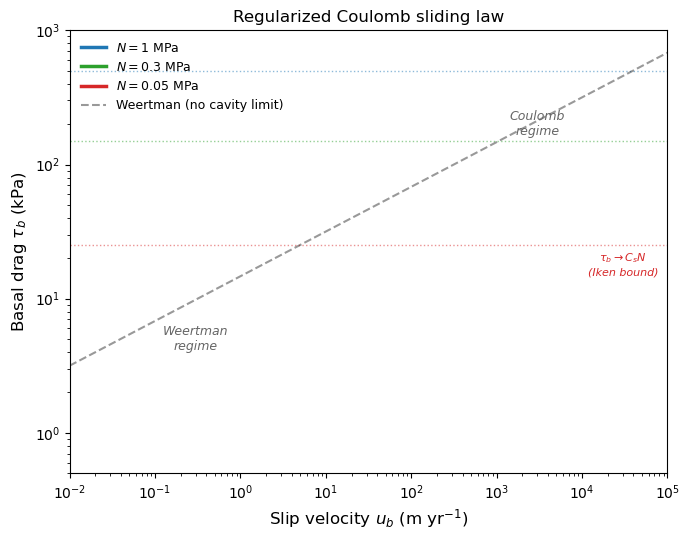

Figure 2 saved.


In [3]:
# ---- Fig 2: drag vs slip velocity (regularized Coulomb law) ----

def tau_b_schoof(u_b, N, C_s, n, A, lambda_max):
    """Schoof (2005) / Gagliardini (2007) sliding law.
    u_b in m/yr, N in Pa, returns tau_b in Pa.
    """
    u_b_si = u_b / sec_per_yr  # convert to m/s
    u_0 = C_s**n * N**n / A * lambda_max
    return C_s * N * (u_b_si / (u_b_si + u_0))**(1.0 / n)


def tau_b_weertman(u_b, C_w, m):
    """Weertman sliding law: tau_b = C_w^{-1/m} u_b^{1/m}.
    u_b in m/yr, returns tau_b in Pa.
    """
    u_b_si = u_b / sec_per_yr
    return C_w**(-1.0/m) * u_b_si**(1.0/m)


# Parameters
n_sl = 3
C_s = 0.5       # Iken's bound coefficient (tan beta)
A_sl = 2.4e-24  # Pa^{-3} s^{-1}
lambda_max = 0.5  # dimensionless, max bed slope parameter

u_b_arr = np.logspace(-2, 5, 1000)  # m/yr

# Three effective pressures
N_vals = [1.0e6, 0.3e6, 0.05e6]  # Pa
N_labels = ['$N = 1$ MPa', '$N = 0.3$ MPa', '$N = 0.05$ MPa']
N_colors = ['#1f77b4', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(7, 5.5))

for N_val, lab, col in zip(N_vals, N_labels, N_colors):
    tau = tau_b_schoof(u_b_arr, N_val, C_s, n_sl, A_sl, lambda_max)
    ax.loglog(u_b_arr, tau / 1e3, '-', color=col, lw=2.5, label=lab)

    # Iken's bound
    iken = C_s * N_val
    ax.axhline(iken / 1e3, color=col, ls=':', lw=1, alpha=0.5)

# Weertman law for reference (calibrated to match N=1 MPa at low velocity)
C_w_ref = 1e-20  # tuned for visual match
tau_w = tau_b_weertman(u_b_arr, C_w_ref, n_sl)
ax.loglog(u_b_arr, tau_w / 1e3, 'k--', lw=1.5, alpha=0.4,
          label='Weertman (no cavity limit)')

# Annotations
ax.annotate('Weertman\nregime', xy=(0.3, 5), fontsize=9,
            ha='center', va='center', color='0.4', style='italic')
ax.annotate('Coulomb\nregime', xy=(3e3, 200), fontsize=9,
            ha='center', va='center', color='0.4', style='italic')
ax.annotate('$\\tau_b \\to C_s N$\n(Iken bound)', xy=(3e4, 15),
            fontsize=8, ha='center', color='#d62728', style='italic')

ax.set_xlabel('Slip velocity $u_b$ (m yr$^{-1}$)', fontsize=12)
ax.set_ylabel('Basal drag $\\tau_b$ (kPa)', fontsize=12)
ax.set_xlim(0.01, 1e5)
ax.set_ylim(0.5, 1000)
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.set_title('Regularized Coulomb sliding law', fontsize=12)

fig.tight_layout()
fig.savefig('figures/fig02_drag_vs_slip_velocity.pdf', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

---
## Figure 3: Sliding Velocity vs Effective Pressure

For a fixed basal shear stress, show how the sliding velocity depends on effective pressure $N = P_i - P_w$ using the Budd-type law $u_b = k \tau_b^p / N^q$. This illustrates the extreme sensitivity of sliding to water pressure.

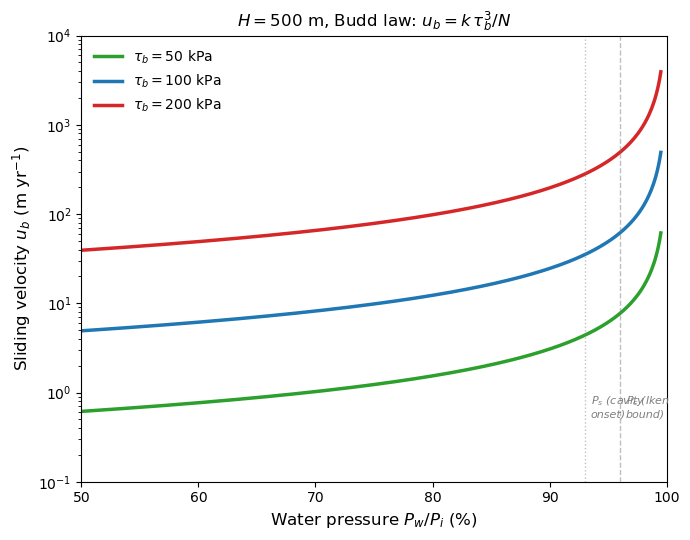

Figure 3 saved.


In [4]:
# ---- Fig 3: sliding velocity vs effective pressure ----

H = 500.0          # m, ice thickness
P_i = rho_i * g * H  # Pa

# Effective pressure as fraction of overburden
Pw_frac = np.linspace(0.5, 0.995, 500)
N_arr = P_i * (1 - Pw_frac)  # Pa

tau_b_vals = [50e3, 100e3, 200e3]  # Pa
tau_labels = ['$\\tau_b = 50$ kPa', '$\\tau_b = 100$ kPa', '$\\tau_b = 200$ kPa']
tau_colors = ['#2ca02c', '#1f77b4', '#d62728']

# Budd-type law: u_b = k * tau_b^3 / N  (p=3, q=1)
k_budd = 3.5e-16  # m Pa^{-2} s^{-1} (representative)

fig, ax = plt.subplots(figsize=(7, 5.5))

for tau_val, lab, col in zip(tau_b_vals, tau_labels, tau_colors):
    u_b = k_budd * tau_val**3 / N_arr  # m/s
    u_b_yr = u_b * sec_per_yr  # m/yr
    ax.semilogy(Pw_frac * 100, u_b_yr, '-', color=col, lw=2.5, label=lab)

# Mark key thresholds
ax.axvline(93, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(93.5, 0.5, '$P_s$ (cavity\nonset)', fontsize=8, color='gray',
        va='bottom', ha='left', style='italic')

ax.axvline(96, color='gray', ls='--', lw=1, alpha=0.5)
ax.text(96.5, 0.5, '$P_c$ (Iken\nbound)', fontsize=8, color='gray',
        va='bottom', ha='left', style='italic')

ax.set_xlabel('Water pressure $P_w / P_i$ (%)', fontsize=12)
ax.set_ylabel('Sliding velocity $u_b$ (m yr$^{-1}$)', fontsize=12)
ax.set_title(f'$H = {H:.0f}$ m, Budd law: $u_b = k\\,\\tau_b^3 / N$', fontsize=12)
ax.set_xlim(50, 100)
ax.set_ylim(0.1, 1e4)
ax.legend(loc='upper left', fontsize=10, frameon=False)

fig.tight_layout()
fig.savefig('figures/fig03_velocity_vs_effective_pressure.pdf', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## Figure 4: Mohr–Coulomb Yield Stress vs Effective Pressure

Show the linear relation $\tau_* = c_o + f N$ for tills with different friction angles, alongside measured values from Table 7.5 of Cuffey & Paterson.

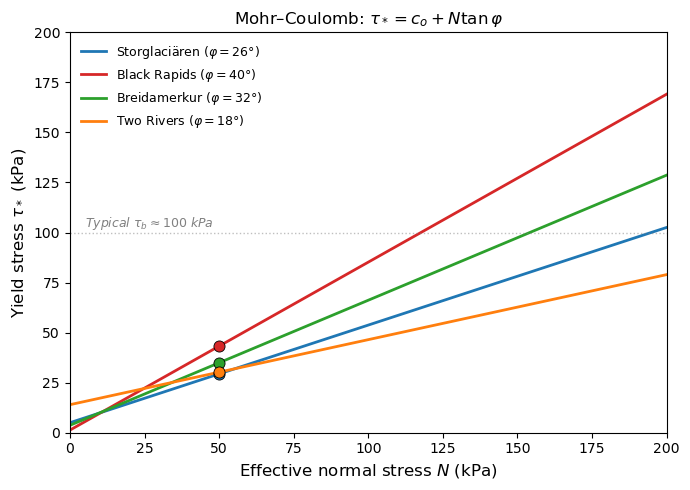

Figure 4 saved.


In [5]:
# ---- Fig 4: Mohr-Coulomb yield stress vs effective pressure ----

N_mc = np.linspace(0, 200, 500)  # kPa

# Friction angles and cohesion from Table 7.5 (Cuffey & Paterson)
tills = [
    {'name': 'Storglaciären', 'phi': 26, 'c_o': 5, 'color': '#1f77b4'},
    {'name': 'Black Rapids', 'phi': 40, 'c_o': 1.3, 'color': '#d62728'},
    {'name': 'Breidamerkur', 'phi': 32, 'c_o': 3.7, 'color': '#2ca02c'},
    {'name': 'Two Rivers', 'phi': 18, 'c_o': 14, 'color': '#ff7f0e'},
]

fig, ax = plt.subplots(figsize=(7, 5))

for till in tills:
    f_val = np.tan(np.radians(till['phi']))
    tau_star = till['c_o'] + f_val * N_mc
    ax.plot(N_mc, tau_star, '-', color=till['color'], lw=2,
            label=f"{till['name']} ($\\varphi = {till['phi']}°$)")
    # Mark the N=50 kPa reference point
    tau_50 = till['c_o'] + f_val * 50
    ax.plot(50, tau_50, 'o', color=till['color'], ms=8,
            markeredgecolor='k', markeredgewidth=0.6, zorder=5)

# Reference: typical glacier basal shear stress
ax.axhline(100, color='gray', ls=':', lw=1, alpha=0.5)
ax.text(5, 103, 'Typical $\\tau_b \\approx 100$ kPa', fontsize=9,
        color='gray', style='italic')

ax.set_xlabel('Effective normal stress $N$ (kPa)', fontsize=12)
ax.set_ylabel('Yield stress $\\tau_*$ (kPa)', fontsize=12)
ax.set_title('Mohr–Coulomb: $\\tau_* = c_o + N \\tan\\varphi$', fontsize=12)
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)
ax.legend(loc='upper left', fontsize=9, frameon=False)

fig.tight_layout()
fig.savefig('figures/fig04_mohr_coulomb.pdf', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## Figure 5: Comparison of Sliding Laws

Show the three sliding laws side by side — Weertman, Budd (effective-pressure-dependent), and regularized Coulomb — plotted as $\tau_b$ vs $u_b$ for a fixed effective pressure. This illustrates the qualitative differences: Weertman grows without bound, Budd grows without bound (but shifted by $N$), and Coulomb saturates at $fN$.

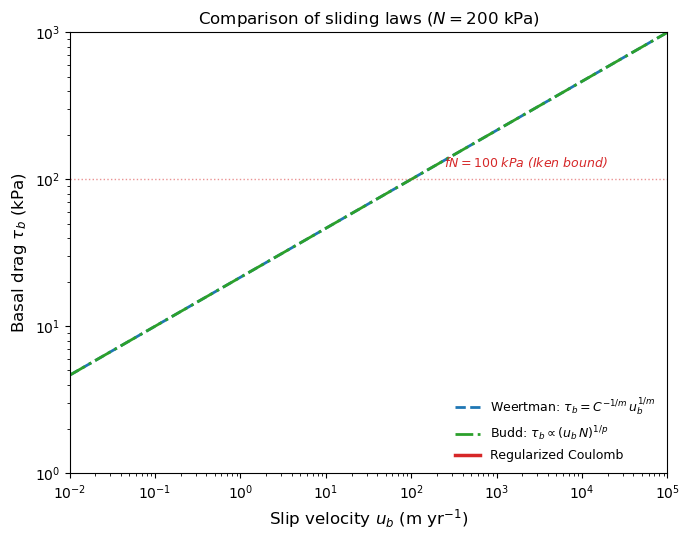

Figure 5 saved.


In [6]:
# ---- Fig 5: comparison of three sliding laws ----

u_b_comp = np.logspace(-2, 5, 1000)  # m/yr
N_comp = 0.2e6  # Pa (200 kPa, moderate effective pressure)

n_c = 3

# 1. Weertman: tau_b = C_w^{-1/m} * u_b^{1/m}
#    Calibrate C_w so that tau_b ~ 100 kPa at u_b ~ 100 m/yr
u_ref = 100 / sec_per_yr  # m/s
tau_ref = 100e3  # Pa
C_w = (u_ref / tau_ref**n_c)  # m/s Pa^{-3}
tau_weertman = (u_b_comp / sec_per_yr / C_w)**(1.0/n_c)

# 2. Budd: tau_b = (u_b * N^q / k)^{1/p}
#    u_b = k * tau_b^p / N^q, with p=3, q=1
#    Calibrate k so same reference point
k_b = u_ref * N_comp / tau_ref**3
tau_budd = (u_b_comp / sec_per_yr * N_comp / k_b)**(1.0/3)

# 3. Regularized Coulomb (Schoof 2005)
C_s_comp = 0.5
lambda_max_comp = 0.5
tau_coulomb = tau_b_schoof(u_b_comp, N_comp, C_s_comp, n_c, A_sl, lambda_max_comp)

fig, ax = plt.subplots(figsize=(7, 5.5))

ax.loglog(u_b_comp, tau_weertman / 1e3, '--', color='#1f77b4', lw=2,
          label='Weertman: $\\tau_b = C^{-1/m}\\,u_b^{1/m}$')
ax.loglog(u_b_comp, tau_budd / 1e3, '-.', color='#2ca02c', lw=2,
          label='Budd: $\\tau_b \\propto (u_b\\,N)^{1/p}$')
ax.loglog(u_b_comp, tau_coulomb / 1e3, '-', color='#d62728', lw=2.5,
          label='Regularized Coulomb')

# Iken/Coulomb bound
iken_bound = C_s_comp * N_comp
ax.axhline(iken_bound / 1e3, color='#d62728', ls=':', lw=1, alpha=0.5)
ax.text(2e4, iken_bound / 1e3 * 1.15, f'$f N = {iken_bound/1e3:.0f}$ kPa (Iken bound)',
        fontsize=9, color='#d62728', ha='right', va='bottom', style='italic')

ax.set_xlabel('Slip velocity $u_b$ (m yr$^{-1}$)', fontsize=12)
ax.set_ylabel('Basal drag $\\tau_b$ (kPa)', fontsize=12)
ax.set_title(f'Comparison of sliding laws ($N = {N_comp/1e3:.0f}$ kPa)', fontsize=12)
ax.set_xlim(0.01, 1e5)
ax.set_ylim(1, 1000)
ax.legend(loc='lower right', fontsize=9, frameon=False)

fig.tight_layout()
fig.savefig('figures/fig05_sliding_law_comparison.pdf', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')